In [1]:
from pathlib import Path

import os 
os.chdir('../')
from src.data.datamodule import MyDataModule
from src.models.lightning_module import RegressionModel
import src.models.models as models
from src.utils.config import load_config, _make_transform, _build_data_slice
from src.utils.trained_models import get_trained_model
from src.utils.config import load_config, _build_data_slice, resolve_task_type



In [2]:

run_id = 'd4c334d9'
config_path = f"outputs/african-rainfall-classification/{run_id}/config.yaml"
checkpoint_path = f"outputs/african-rainfall-classification/{run_id}/checkpoints/best.ckpt"
run_output_dir = Path(f"outputs/african-rainfall-classification/{run_id}")
checkpoint_file = Path(checkpoint_path)
checkpoint_path = str(checkpoint_file)
# Load configuration file
config = load_config(config_path)


In [3]:
lightning_model, trainer, datamodule = get_trained_model(config, checkpoint_path)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [4]:
datamodule.setup('fit')
# predictions = trainer.

Fitting transforms on the training data...


In [12]:
import torch 
task_type = resolve_task_type(config)
forecast_horizon_days = int(
    config["data"].get("forecast_horizon_days", config["data"].get("forecast_horizon_weeks", 0))
)
horizon_steps = forecast_horizon_days + 1

# Make all predictions and concatenate the results into tensors for predictions, targets, and time indices.
prediction_batches = trainer.predict(lightning_model, datamodule=datamodule)
if task_type == "classification":
    pred_classes = torch.cat([batch[0].detach().cpu() for batch in prediction_batches], dim=0)
    pred_pos_prob = torch.cat([batch[1].detach().cpu() for batch in prediction_batches], dim=0)
    targets = torch.cat([batch[2].detach().cpu() for batch in prediction_batches], dim=0)
    if pred_classes.ndim == 1:
        pred_classes = pred_classes.unsqueeze(-1)
    if pred_pos_prob.ndim == 1:
        pred_pos_prob = pred_pos_prob.unsqueeze(-1)
    if targets.ndim == 1:
        targets = targets.unsqueeze(-1)
    time_indices = torch.cat([batch[3].detach().cpu() for batch in prediction_batches], dim=0).numpy()
else:
    preds = torch.cat([batch[0].detach().cpu() for batch in prediction_batches], dim=0)
    targets = torch.cat([batch[1].detach().cpu() for batch in prediction_batches], dim=0)
    if preds.ndim == 1:
        preds = preds.unsqueeze(-1)
    if targets.ndim == 1:
        targets = targets.unsqueeze(-1)
    time_indices = torch.cat([batch[2].detach().cpu() for batch in prediction_batches], dim=0).numpy()
    # If the prediction is negative, set it to 0, since rainfall cannot be negative.
    preds = torch.clamp(preds, min=0.0)


/opt/anaconda3/envs/bccr-ml/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Predicting: |          | 0/? [00:00<?, ?it/s]

In [15]:
prediction_batches

[(tensor([[0, 0, 0,  ..., 0, 0, 1],
          [0, 0, 0,  ..., 0, 0, 1],
          [0, 0, 0,  ..., 0, 0, 1],
          ...,
          [1, 1, 1,  ..., 0, 0, 0],
          [1, 1, 1,  ..., 0, 0, 0],
          [1, 1, 1,  ..., 1, 0, 0]]),
  tensor([[0.2045, 0.4191, 0.2556,  ..., 0.4075, 0.3258, 0.5044],
          [0.1961, 0.3247, 0.2280,  ..., 0.3872, 0.3520, 0.5039],
          [0.1592, 0.2100, 0.1567,  ..., 0.3753, 0.3815, 0.5014],
          ...,
          [0.8252, 0.7697, 0.7290,  ..., 0.4952, 0.4429, 0.4344],
          [0.7980, 0.7380, 0.7316,  ..., 0.4847, 0.4213, 0.4098],
          [0.8268, 0.8104, 0.7917,  ..., 0.5291, 0.4720, 0.4906]]),
  tensor([[0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          ...,
          [1, 1, 0,  ..., 0, 0, 0],
          [1, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0]]),
  tensor([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
           14,  15,  16,  17,  18,  19,  

In [19]:
data_slices[-1000:]

array(['test', 'test', 'test', 'test', 'test', 'test', 'test', 'test',
       'test', 'test', 'test', 'test', 'test', 'test', 'test', 'test',
       'test', 'test', 'test', 'test', 'test', 'test', 'test', 'test',
       'test', 'test', 'test', 'test', 'test', 'test', 'test', 'test',
       'test', 'test', 'test', 'test', 'test', 'test', 'test', 'test',
       'test', 'test', 'test', 'test', 'test', 'test', 'test', 'test',
       'test', 'test', 'test', 'test', 'test', 'test', 'test', 'test',
       'test', 'test', 'test', 'test', 'test', 'test', 'test', 'test',
       'test', 'test', 'test', 'test', 'test', 'test', 'test', 'test',
       'test', 'test', 'test', 'test', 'test', 'test', 'test', 'test',
       'test', 'test', 'test', 'test', 'test', 'test', 'test', 'test',
       'test', 'test', 'test', 'test', 'test', 'test', 'test', 'test',
       'test', 'test', 'test', 'test', 'test', 'test', 'test', 'test',
       'test', 'test', 'test', 'test', 'test', 'test', 'test', 'test',
      

In [21]:
# Compute PR-AUC (Average Precision) per horizon and per data split (train, val, test).
from sklearn.metrics import average_precision_score
import pandas as pd

if task_type != "classification":
    raise ValueError("This cell is for classification only (task_type must be 'classification').")

# Map each prediction to its original time and split label.
times = datamodule.dataset_predict.times[time_indices]
years_split = (datamodule.train_years, datamodule.val_years, datamodule.test_years)
data_slices = _build_data_slice(times, years_split)

rows = []
for h in range(horizon_steps):
    y_true_h = targets[:, h].numpy()
    y_score_h = pred_pos_prob[:, h].numpy()

    for split in [ "val"]:
        mask = data_slices == split
        if mask.sum() == 0:
            pr_auc = float("nan")
            n_samples = 0
        else:
            y_true_split = y_true_h[mask]
            y_score_split = y_score_h[mask]
            # PR-AUC is undefined if a split has only one class.
            if len(set(y_true_split.tolist())) < 2:
                pr_auc = float("nan")
            else:
                pr_auc = average_precision_score(y_true_split, y_score_split)
            n_samples = int(mask.sum())

        rows.append(
            {
                "horizon_day": h,
                "split": split,
                "pr_auc": pr_auc,
                "n_samples": n_samples,
            }
        )

pr_auc_by_horizon_split = pd.DataFrame(rows)
pr_auc_pivot = pr_auc_by_horizon_split.pivot(index="horizon_day", columns="split", values="pr_auc")

display(pr_auc_by_horizon_split.head(12))
display(pr_auc_pivot)

,horizon_day,split,pr_auc,n_samples
0,0,val,0.351150,2191
1,1,val,0.314250,2191
2,2,val,0.251213,2191
3,3,val,0.213962,2191
4,4,val,0.192848,2191
5,5,val,0.201471,2191
6,6,val,0.192601,2191
7,7,val,0.202195,2191
8,8,val,0.198459,2191
9,9,val,0.182951,2191


split,val
horizon_day,
0,0.351150
1,0.314250
2,0.251213
3,0.213962
4,0.192848
5,0.201471
6,0.192601
7,0.202195
8,0.198459


<Axes: xlabel='horizon_day'>

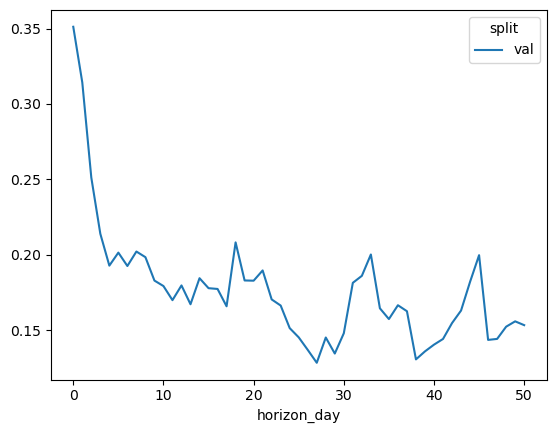

In [23]:
pr_auc_pivot.plot()

In [15]:
import torch
y_tensor = torch.stack([datamodule.dataset_train[k]['y'] for k in range(len(datamodule.dataset_train))])

(array([9715.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
         512.]),
 array([0.        , 0.1       , 0.2       , 0.30000001, 0.40000001,
        0.5       , 0.60000002, 0.69999999, 0.80000001, 0.90000004,
        1.        ]),
 <BarContainer object of 10 artists>)

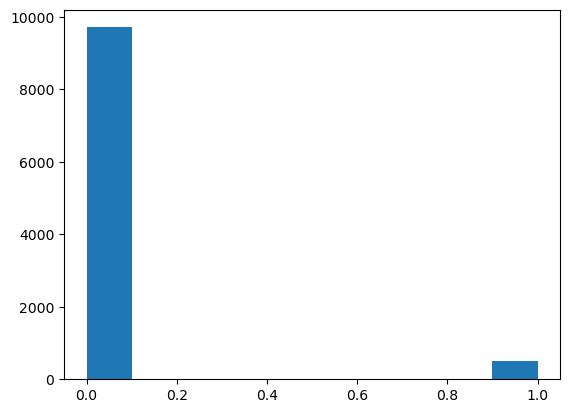

In [20]:
import matplotlib.pyplot as plt
plt.hist(y_tensor.numpy().squeeze())

In [141]:
lightning_model.eval()
lightning_model.freeze()  # Freeze the model to prevent further training

RegressionModel(
  (model): ThreeLayerCNN(
    (relu): ReLU()
    (conv1): Conv2d(4, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (maxpool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (maxpool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (flatten): Flatten(start_dim=1, end_dim=-1)
    (fc1): LazyLinear(in_features=0, out_features=64, bias=True)
    (fc2): Linear(in_features=64, out_features=1, bias=True)
  )
  (criterion): MSELoss()
)

In [142]:
datamodule.setup(stage='test')  # Ensure the test dataset is prepared
X_test = datamodule.test_dataloader().dataset[100]['x'].unsqueeze(0)  # Assuming the first tensor is the input features
y_test = datamodule.test_dataloader().dataset[100]['y'].unsqueeze(0)  # Assuming the first tensor is the target values

Fitting transforms on the training data...


In [143]:
from captum.attr import IntegratedGradients

ig = IntegratedGradients(lightning_model)

In [144]:
lightning_model(X_test)  # Add batch dimension
X_test.requires_grad = True

In [145]:
from zennit.composites import LayerMapComposite, EpsilonPlus
from zennit.rules import Pass, AlphaBeta, Gamma, ZPlus, Norm, Epsilon
from torch.nn import BatchNorm2d, Conv2d, Linear

composite_Zplus = LayerMapComposite([
(BatchNorm2d, Pass()),
(Conv2d, ZPlus()),
(Linear, Norm()),
])

composite_alpha2beta1 = LayerMapComposite([
(BatchNorm2d, Pass()),
(Conv2d, AlphaBeta(2,1)),
(Linear, Norm()),
])
composite_epsilon = LayerMapComposite([
(BatchNorm2d, Pass()),
(Conv2d, Epsilon()),
(Linear, Norm()),
])

composite_gamma = LayerMapComposite([
(BatchNorm2d, Pass()),
(Conv2d, Gamma()),
(Linear, Norm()),
])


In [161]:
import torch
with composite_Zplus.context(lightning_model) as modified_model:
    output = modified_model(X_in)
    obj = output[:, :].sum()
    attribution_zplus, = torch.autograd.grad(obj, X_in, grad_outputs=torch.ones_like(obj))

attributions_xr_zplus = xr.DataArray(
    attribution_zplus.squeeze(0).detach().numpy(),
    dims=["sample","variable", "latitude", "longitude"],
    coords={"variable": variables, "latitude": lat, "longitude": lon},
)




/var/folders/1r/6t41yy7j4tz9t_z8v3bwthb40000gn/T/ipykernel_37067/773797131.py:4: FutureWarning: self.axes is deprecated since 2022.11 in order to align with matplotlibs plt.subplots, use self.axs instead.
  for ax in plot.axes.flat:
/opt/anaconda3/envs/bccr-ml/lib/python3.13/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/envs/bccr-ml/lib/python3.13/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/bccr-ml/lib/python3.13/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/envs/bccr-ml/lib/python3.13/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/bccr-ml/lib/python3.13/site-packages/shapely/constructive.py:246: Run

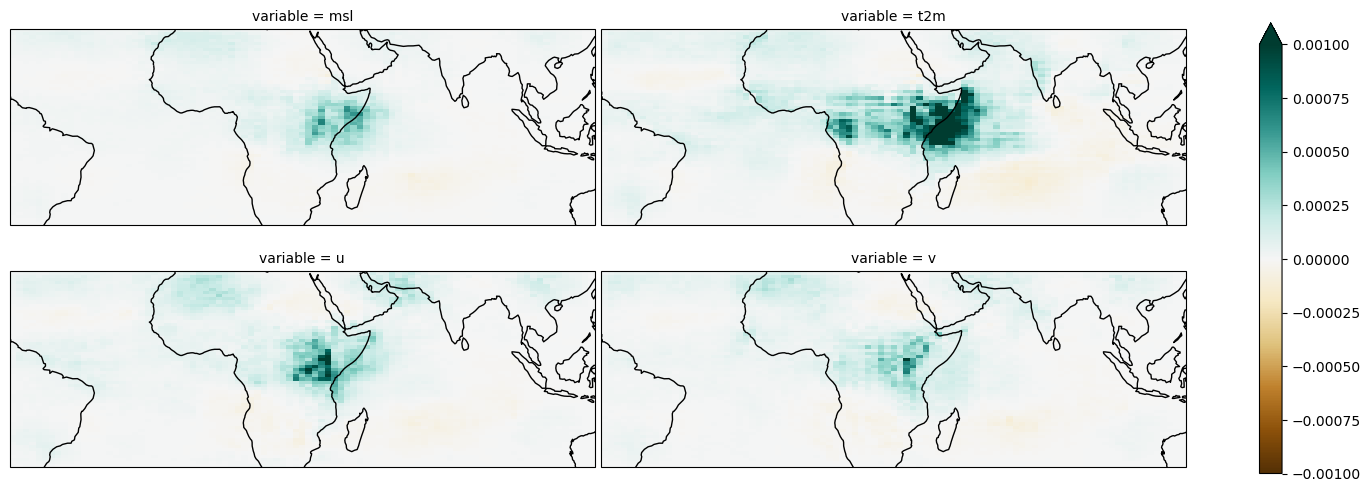

In [163]:
plot = attributions_xr_zplus.mean('sample').plot(col="variable", col_wrap=2, cmap="BrBG", robust=True, figsize=(15,5),
                        subplot_kws = dict(projection=ccrs.PlateCarree()),vmax=0.001,
                        transform=ccrs.PlateCarree(),)  
for ax in plot.axes.flat:
    ax.coastlines()

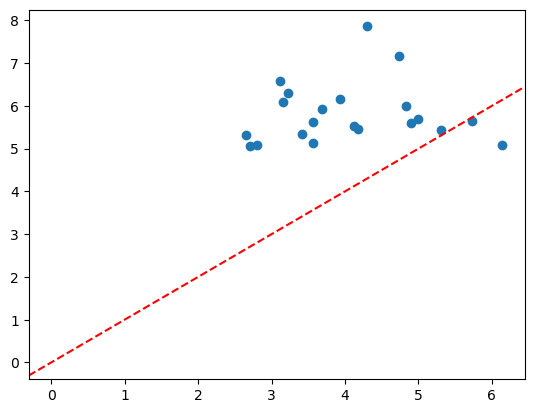

In [155]:
plt.plot(lightning_model(X_in).detach().numpy(), y_in.detach().numpy(), 'o')
plt.axline((0,0), slope=1, color='r', linestyle='--')

In [156]:
X_stack = [datamodule.dataset_test[k]['x'] if datamodule.dataset_test[k]['y'] > 5 else None for k in range(1000)]
X_in = torch.stack([x for x in X_stack if x is not None]).requires_grad_()
y_stack = [datamodule.dataset_test[k]['y'] for k in range(1000) if datamodule.dataset_test[k]['y'] > 5]
y_in = torch.stack([y for y in y_stack if y is not None])

X_in 

tensor([[[[ 1.7233e+00,  1.5740e+00,  1.4019e+00,  ..., -1.0739e+00,
           -1.0597e+00, -7.9938e-01],
          [ 1.6693e+00,  1.5108e+00,  1.3172e+00,  ..., -1.1638e+00,
           -1.1820e+00, -1.0392e+00],
          [ 1.5617e+00,  1.3932e+00,  1.1884e+00,  ..., -1.2522e+00,
           -1.2515e+00, -1.1016e+00],
          ...,
          [-4.6427e-01, -3.5472e-01, -2.8950e-01,  ..., -1.2434e-01,
            2.1898e-02,  1.7093e-01],
          [-4.9639e-01, -3.7371e-01, -3.0699e-01,  ..., -8.8811e-02,
            4.3376e-02,  1.8075e-01],
          [-5.4000e-01, -4.1001e-01, -3.4850e-01,  ..., -7.8334e-02,
            8.2725e-02,  2.1344e-01]],

         [[-1.8122e+00, -1.8461e+00, -1.8766e+00,  ..., -4.5825e-01,
           -2.0044e-01, -3.4143e-01],
          [-1.7952e+00, -1.8299e+00, -1.7163e+00,  ..., -1.0069e-01,
            3.5751e-01,  4.1067e-01],
          [-1.6778e+00, -1.6472e+00, -1.4677e+00,  ...,  6.7253e-01,
            7.8840e-01,  7.7338e-01],
          ...,
     

In [157]:
lon = datamodule.dataset_test.ds.longitude
lat = datamodule.dataset_test.ds.latitude
variables = datamodule.dataset_test.ds.var_name.values

In [158]:
attributions = ig.attribute(X_test.unsqueeze(0))
import xarray as xr
attributions_xr = xr.DataArray(
    attributions.squeeze(0).detach().numpy(),
    dims=["variable", "latitude", "longitude"],
    coords={"variable": variables, "latitude": lat, "longitude": lon},
)



RuntimeError: Expected 3D (unbatched) or 4D (batched) input to conv2d, but got input of size: [50, 1, 4, 61, 91]

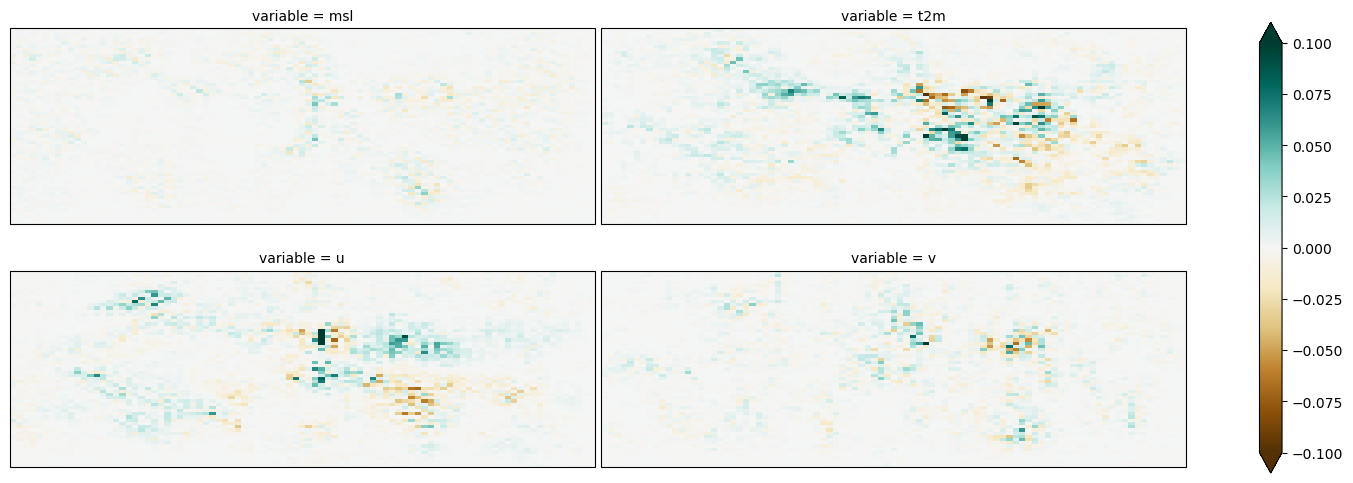

In [159]:
attributions_xr.plot(col="variable", col_wrap=2, cmap="BrBG", robust=True, figsize=(15,5),
                     subplot_kws = dict(projection=ccrs.PlateCarree()),vmax=0.1,
                     transform=ccrs.PlateCarree(),)

In [160]:
attributions_xr_zplus.plot(col="variable", col_wrap=2, cmap="BrBG", robust=True, figsize=(15,5),
                     subplot_kws = dict(projection=ccrs.PlateCarree()),vmax=0.001,
                     transform=ccrs.PlateCarree(),)

ValueError: Only 1d and 2d plots are supported for facets in xarray. See the package `Seaborn` for more options.

/opt/anaconda3/envs/bccr-ml/lib/python3.13/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/envs/bccr-ml/lib/python3.13/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/bccr-ml/lib/python3.13/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/envs/bccr-ml/lib/python3.13/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/bccr-ml/lib/python3.13/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/envs/bccr-ml/lib/python3.13/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects

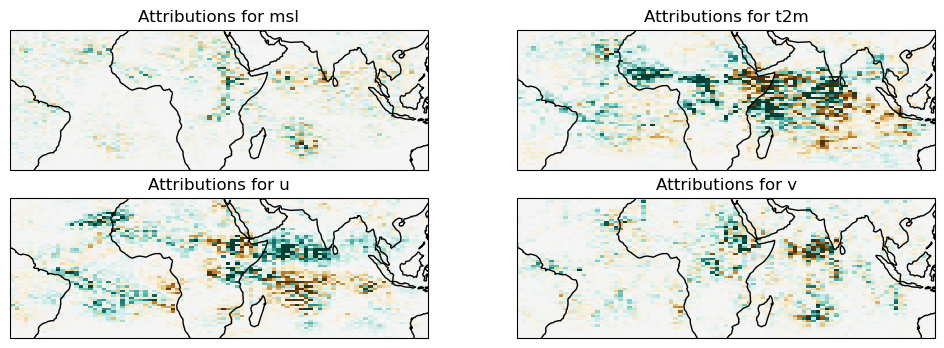

In [63]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
fig, axs = plt.subplots(2,2, subplot_kw = dict(projection=ccrs.PlateCarree()), figsize=(12, 4))
axs[0,0].pcolormesh(lon, lat, attributions[0][0], vmax = 0.03, vmin=-0.03, cmap='BrBG', transform=ccrs.PlateCarree(),)
axs[0,1].pcolormesh(lon, lat, attributions[0][1], vmax = 0.03, vmin=-0.03, cmap='BrBG', transform=ccrs.PlateCarree(),)
axs[1,0].pcolormesh(lon, lat, attributions[0][2], vmax = 0.03, vmin=-0.03, cmap='BrBG', transform=ccrs.PlateCarree(),)
axs[1,1].pcolormesh(lon, lat, attributions[0][3], vmax = 0.03, vmin=-0.03, cmap='BrBG', transform=ccrs.PlateCarree(),)

for k,ax in enumerate(axs.flat):
    ax.coastlines()
    ax.set_title(f'Attributions for {variables[k]}')